<a href="https://colab.research.google.com/github/annaz201816/search/blob/main/search_164.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Tile Sliding Puzzle Search Evaluation (3x3 and 4x4)

import random
import heapq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Globals
StateDimension = 3
MAX_NODE_LIMIT = 100000  # Limit to prevent long runtimes, otherwise takes too long

def setStateDimension(n):
    global StateDimension
    StateDimension = n

Actions = lambda s: ['u', 'd', 'l', 'r']
Opposite = dict([('u','d'),('d','u'),('l','r'),('r','l'), (None, None)])


In [ ]:
def Result(state, action):
    i = state.index(0)
    newState = list(state)
    row, col = i // StateDimension, i % StateDimension
    if ((action == 'u' and row == 0) or
        (action == 'd' and row == StateDimension - 1) or
        (action == 'l' and col == 0) or
        (action == 'r' and col == StateDimension - 1)):
        return newState
    if action == 'u':
        l, r = row * StateDimension + col, (row - 1) * StateDimension + col
    elif action == 'd':
        l, r = row * StateDimension + col, (row + 1) * StateDimension + col
    elif action == 'l':
        l, r = row * StateDimension + col, row * StateDimension + col - 1
    elif action == 'r':
        l, r = row * StateDimension + col, row * StateDimension + col + 1
    newState[l], newState[r] = newState[r], newState[l]
    return newState

def LegalMove(state, action):
    i = state.index(0)
    row, col = i // StateDimension, i % StateDimension
    if ((action == 'u' and row == 0) or
        (action == 'd' and row == StateDimension - 1) or
        (action == 'l' and col == 0) or
        (action == 'r' and col == StateDimension - 1)):
        return False
    return True

def RandomWalk(state, steps):
    actionSequence = []
    actionLast = None
    for _ in range(steps):
        action = None
        while action is None:
            action = random.choice(Actions(state))
            if not LegalMove(state, action) or action == Opposite[actionLast]:
                action = None
        actionLast = action
        state = Result(state, action)
        actionSequence.append(action)
    return state, actionSequence

def SingleTileManhattanDistance(tile, left, right):
    leftIndex = left.index(tile)
    rightIndex = right.index(tile)
    return abs(leftIndex // StateDimension - rightIndex // StateDimension) + \
           abs(leftIndex % StateDimension - rightIndex % StateDimension)

def ManhattanDistance(left, right):
    return sum(SingleTileManhattanDistance(tile, left, right) for tile in range(1, StateDimension ** 2))

def OutOfPlace(left, right):
    return sum(1 for i in range(StateDimension ** 2) if left[i] != right[i] and right[i] != 0)


In [ ]:
class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.State = state
        self.Parent = parent
        self.Action = action
        self.PathCost = path_cost
    def __lt__(self, other):
        return self.PathCost < other.PathCost

def Expand(problem, node):
    ret = []
    for action in problem['Actions'](node.State):
        sPrime = problem['Result'](node.State, action)
        cost = node.PathCost + problem['ActionCost'](node.State, action, sPrime)
        ret.append(Node(sPrime, node, action, cost))
    return ret

def BreadthFirstSearch(problem):
    node = Node(problem['INITIAL'])
    if problem['IsGoal'](node.State):
        return node, 0
    Frontier = [node]
    reached = {tuple(problem['INITIAL'])}
    nodesExpanded = 0
    while Frontier:
        node = Frontier.pop(0)
        for child in Expand(problem, node):
            s = tuple(child.State)
            if problem['IsGoal'](s):
                return child, nodesExpanded
            if s not in reached:
                reached.add(s)
                Frontier.append(child)
        nodesExpanded += 1
        if nodesExpanded > MAX_NODE_LIMIT:
            return None, nodesExpanded
    return None, nodesExpanded

def BestFirstSearch(problem, f):
    node = Node(problem['INITIAL'])
    Frontier = []
    heapq.heappush(Frontier, (f(node), node))
    reached = {tuple(problem['INITIAL']): node}
    nodesExpanded = 0
    while Frontier:
        _, node = heapq.heappop(Frontier)
        if problem['IsGoal'](tuple(node.State)):
            return node, nodesExpanded
        for child in Expand(problem, node):
            s = tuple(child.State)
            if s not in reached or child.PathCost < reached[s].PathCost:
                reached[s] = child
                heapq.heappush(Frontier, (f(child), child))
        nodesExpanded += 1
        if nodesExpanded > MAX_NODE_LIMIT:
            return None, nodesExpanded
    return None, nodesExpanded

def Solution(node):
    if node.Parent is None:
        return []
    return Solution(node.Parent) + [node.Action]

def printBoard(state):
    for i in range(StateDimension):
        print(state[i * StateDimension:(i + 1) * StateDimension])
    print()

def runExperiments(dimension):
    print(f"\n===== Running Experiments for {dimension}x{dimension} Puzzle =====")
    setStateDimension(dimension)
    N = StateDimension * StateDimension
    GoalState = list(range(1, N)) + [0]
    BaseState = GoalState.copy()
    stepsList = [5, 10, 20, 40, 80]
    problems = []

    for steps in stepsList:
        for i in range(3):
            s, _ = RandomWalk(BaseState.copy(), steps)
            print(f"\n🔁 Random Walk (steps={steps}) [{i+1}/3]")
            print("Initial State:")
            printBoard(s)
            problems.append(s)

    results = []
    for idx, init in enumerate(problems):
        print(f"\n🚀 Evaluating Problem {idx+1}/{len(problems)}")
        problem = {
            'INITIAL': init,
            'IsGoal': lambda s, goal=GoalState: list(s) == goal,
            'Actions': Actions,
            'Result': Result,
            'ActionCost': lambda s, a, sp: 1
        }

        if dimension == 3:
            print("🔍 Breadth-First Search")
            bfs_result, bfs_nodes = BreadthFirstSearch(problem)
            bfs_sol = Solution(bfs_result) if bfs_result else []
            print(f"  ✔ Solution Length: {len(bfs_sol)}")
            print(f"  ✔ Nodes Expanded: {bfs_nodes}")
            results.append({
                'dimension': dimension,
                'initial': tuple(init),
                'method': 'BFS',
                'solution_length': len(bfs_sol),
                'nodes_expanded': bfs_nodes
            })

        print("🌟 A* Search (Manhattan Distance)")
        a_star_m_result, a_star_m_nodes = BestFirstSearch(problem, lambda n: n.PathCost + ManhattanDistance(n.State, GoalState))
        a_star_m_sol = Solution(a_star_m_result) if a_star_m_result else []
        print(f"  ✔ Solution Length: {len(a_star_m_sol)}")
        print(f"  ✔ Nodes Expanded: {a_star_m_nodes}")
        results.append({
            'dimension': dimension,
            'initial': tuple(init),
            'method': 'A*_Manhattan',
            'solution_length': len(a_star_m_sol),
            'nodes_expanded': a_star_m_nodes
        })

        print("🌟 A* Search (Out-of-Place Heuristic)")
        a_star_o_result, a_star_o_nodes = BestFirstSearch(problem, lambda n: n.PathCost + OutOfPlace(n.State, GoalState))
        a_star_o_sol = Solution(a_star_o_result) if a_star_o_result else []
        print(f"  ✔ Solution Length: {len(a_star_o_sol)}")
        print(f"  ✔ Nodes Expanded: {a_star_o_nodes}")
        results.append({
            'dimension': dimension,
            'initial': tuple(init),
            'method': 'A*_OutOfPlace',
            'solution_length': len(a_star_o_sol),
            'nodes_expanded': a_star_o_nodes
        })

    return results



===== Running Experiments for 3x3 Puzzle =====

🔁 Random Walk (steps=5) [1/3]
Initial State:
[4, 1, 3]
[0, 2, 5]
[7, 8, 6]


🔁 Random Walk (steps=5) [2/3]
Initial State:
[1, 2, 3]
[7, 4, 5]
[8, 0, 6]


🔁 Random Walk (steps=5) [3/3]
Initial State:
[1, 2, 3]
[7, 4, 6]
[5, 0, 8]


🔁 Random Walk (steps=10) [1/3]
Initial State:
[5, 1, 3]
[4, 0, 6]
[7, 2, 8]


🔁 Random Walk (steps=10) [2/3]
Initial State:
[1, 2, 3]
[7, 6, 8]
[0, 5, 4]


🔁 Random Walk (steps=10) [3/3]
Initial State:
[2, 5, 3]
[4, 1, 6]
[7, 8, 0]


🔁 Random Walk (steps=20) [1/3]
Initial State:
[0, 1, 3]
[2, 7, 6]
[4, 5, 8]


🔁 Random Walk (steps=20) [2/3]
Initial State:
[5, 1, 2]
[4, 6, 3]
[0, 7, 8]


🔁 Random Walk (steps=20) [3/3]
Initial State:
[4, 8, 2]
[7, 0, 3]
[5, 1, 6]


🔁 Random Walk (steps=40) [1/3]
Initial State:
[4, 8, 2]
[7, 0, 3]
[5, 1, 6]


🔁 Random Walk (steps=40) [2/3]
Initial State:
[6, 7, 0]
[1, 8, 4]
[3, 5, 2]


🔁 Random Walk (steps=40) [3/3]
Initial State:
[5, 7, 1]
[4, 0, 2]
[8, 6, 3]


🔁 Random Walk (ste

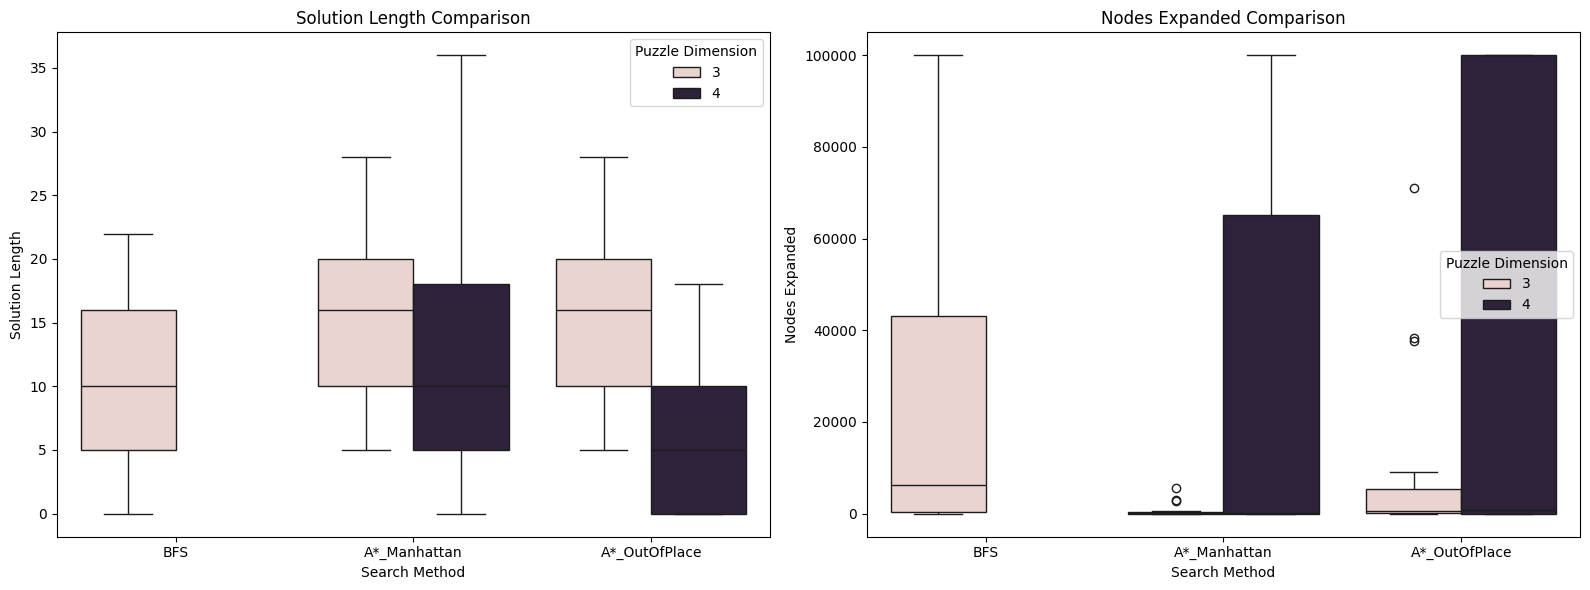

In [ ]:
# Run and display results
results_3x3 = runExperiments(3)
results_4x4 = runExperiments(4)
all_results = pd.DataFrame(results_3x3 + results_4x4)
print("\n✅ Final Results DataFrame:")
print(all_results)

# Save to CSV
# all_results.to_csv("tile_puzzle_results.csv", index=False)

# Plot the results
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=all_results, x='method', y='solution_length', hue='dimension')
plt.title('Solution Length Comparison')
plt.xlabel('Search Method')
plt.ylabel('Solution Length')
plt.legend(title='Puzzle Dimension')

plt.subplot(1, 2, 2)
sns.boxplot(data=all_results, x='method', y='nodes_expanded', hue='dimension')
plt.title('Nodes Expanded Comparison')
plt.xlabel('Search Method')
plt.ylabel('Nodes Expanded')
plt.legend(title='Puzzle Dimension')

plt.tight_layout()
plt.show()
